In [1]:
import numpy as np
import pandas as pd

In [2]:
data = '/content/ACTIVITIES_DEC18_corrected.csv'

In [3]:
df = pd.read_csv(data)

In [4]:
df.head(3)

,HHID,INDIVID,ACT_DAY,ACT_ID,STOP_ID,StartTime,EndTime,Mode_id1,MODE_NAME,numAccomp,...,lat,lon,actdur,sz,citycode,taz,dateNEW,reason,TourStart,tourID
0,2250000572,225000057201,10,1,19659500.0,21/03/2017 03:00,21/03/2017 10:01,3,Vehicle as Driver,0,...,32.770523,35.046902,421.516667,18.0,2500.0,1803.0,21/03/2017,NaN,1.0,1.0
1,2250000572,225000057201,10,2,19664094.0,21/03/2017 10:05,21/03/2017 18:31,1,Pedestrian,0,...,32.770587,35.044223,505.683333,18.0,2500.0,1803.0,21/03/2017,NaN,0.0,1.0
2,2250000572,225000057201,10,2,19664094.0,21/03/2017 10:05,21/03/2017 18:31,1,Pedestrian,0,...,32.770587,35.044223,505.683333,18.0,2500.0,1803.0,21/03/2017,NaN,1.0,2.0


In [5]:
df.columns

Index(['HHID', 'INDIVID', 'ACT_DAY', 'ACT_ID', 'STOP_ID', 'StartTime',
       'EndTime', 'Mode_id1', 'MODE_NAME', 'numAccomp', 'accompType',
       'parkType', 'parkFee', 'activities', 'otherActivity', 'mainActivity',
       'lat', 'lon', 'actdur', 'sz', 'citycode', 'taz', 'dateNEW', 'reason',
       'TourStart', 'tourID'],
      dtype='object')

In [ ]:
create two sets, slice by: ACT_DAY = 10, ACT_DAY = 20
order by ACT_ID ascending
group by INDIVID, TourID
origin = taz of the previous ACT_ID
destination = taz of the current ACT_ID
if mainActivity = Home, take EndTime as leaving
if mainActivity != Home, take StartTime as leaving
filter for leaving time between 6:00 and 9:00
outcome: matrix between taz, count ACT_ID


In [7]:
def process_day(df_day):
    # Sort and group
    df_sorted = df_day.sort_values(by=['INDIVID', 'tourID', 'ACT_ID'])

    # Get origin (taz of previous ACT_ID)
    df_sorted['origin'] = df_sorted.groupby(['INDIVID', 'tourID'])['taz'].shift(1)
    df_sorted['destination'] = df_sorted['taz']

    # Determine leaving time with explicit dayfirst=True
    df_sorted['StartTime'] = pd.to_datetime(df_sorted['StartTime'], dayfirst=True)
    df_sorted['EndTime'] = pd.to_datetime(df_sorted['EndTime'], dayfirst=True)

    df_sorted['leaving_time'] = np.where(
        df_sorted['mainActivity'] == 'Home',
        df_sorted['EndTime'],
        df_sorted['StartTime']
    )

    # Filter for leaving time between 6:00 and 9:00
    mask = (df_sorted['leaving_time'].dt.hour >= 6) & (df_sorted['leaving_time'].dt.hour < 9)
    df_filtered = df_sorted[mask].dropna(subset=['origin', 'destination'])

    # Outcome: matrix between taz (origin/destination), count ACT_ID
    matrix = pd.crosstab(df_filtered['origin'], df_filtered['destination'])
    return matrix

# Slice by ACT_DAY = 10 and 20
df_10 = df[df['ACT_DAY'] == 10].copy()
df_20 = df[df['ACT_DAY'] == 20].copy()

matrix_10 = process_day(df_10)
matrix_20 = process_day(df_20)

print("Matrix for Day 10 shape:", matrix_10.shape)
print("Matrix for Day 20 shape:", matrix_20.shape)

# Displaying head of Matrix 10 as sample
display(matrix_10.head())

Matrix for Day 10 shape: (579, 678)
Matrix for Day 20 shape: (566, 665)


destination,0.0,101.0,102.0,103.0,104.0,105.0,106.0,107.0,108.0,109.0,...,4012.0,4013.0,4014.0,4015.0,4016.0,4017.0,4018.0,4019.0,4021.0,4022.0
origin,,,,,,,,,,,,,,,,,,,,,
0.0,82,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
101.0,0,6,1,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
102.0,0,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
106.0,1,0,0,0,0,0,4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
107.0,0,0,0,3,0,1,2,13,2,1,...,0,0,0,0,0,0,0,0,0,0


In [9]:
matrix_10.sum().sum()

np.int64(11303)

In [11]:
# Calculate probability matrices by dividing each row by the total trips from that origin
prob_matrix_10 = matrix_10.div(matrix_10.sum(axis=1), axis=0).fillna(0)
prob_matrix_20 = matrix_20.div(matrix_20.sum(axis=1), axis=0).fillna(0)

print("Probability Matrix 10 (first 5 rows/cols):")
display(prob_matrix_10.iloc[:5, :5])

print("\nProbability Matrix 20 (first 5 rows/cols):")
display(prob_matrix_20.iloc[:5, :5])

Probability Matrix 10 (first 5 rows/cols):


destination,0.0,101.0,102.0,103.0,104.0
origin,,,,,
0.0,0.942529,0.000,0.0000,0.000000,0.0
101.0,0.000000,0.375,0.0625,0.000000,0.0
102.0,0.000000,0.000,0.5000,0.000000,0.0
106.0,0.111111,0.000,0.0000,0.000000,0.0
107.0,0.000000,0.000,0.0000,0.085714,0.0



Probability Matrix 20 (first 5 rows/cols):


destination,0.0,101.0,102.0,103.0,104.0
origin,,,,,
0.0,0.962264,0.000000,0.000000,0.0,0.0
101.0,0.000000,0.368421,0.052632,0.0,0.0
102.0,0.000000,0.000000,0.400000,0.0,0.0
105.0,0.000000,0.000000,0.000000,0.0,0.0
106.0,0.000000,0.166667,0.000000,0.0,0.0


In [13]:
cellular = pd.read_csv('/content/AvgDayHourlyTrips201819_1270_weekday_v1.csv')

In [14]:
cellular.head(3)

,fromZone,ToZone,h0,h1,h2,h3,h4,h5,h6,h7,...,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23
0,100978,100978,12.656234,6.409174,4.030500,3.420190,4.057672,7.932251,38.818453,51.898641,...,66.997064,68.905661,70.105602,51.477799,42.444791,40.402213,35.723462,30.320712,22.382904,16.212404
1,100978,100979,71.531978,34.744616,22.288482,15.754996,17.464689,41.559129,95.694266,140.688155,...,287.066376,323.089907,302.181914,258.308701,231.942070,236.466321,238.511916,197.413326,142.125720,91.730832
2,100978,100980,8.216579,6.243406,4.697553,4.628329,9.045714,23.797157,29.410763,42.917967,...,54.675934,51.742902,42.329777,30.869347,26.466300,21.880208,21.135352,18.409541,15.707458,11.605627


In [15]:
cellular = cellular[['fromZone','ToZone','h6','h7','h8']]

In [17]:
keys = pd.read_csv('/content/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')

In [18]:
keys.head()

,ID,TAZ_1270,TAZ_250,TAZ_33,TAZ_15,CITY,NEIGHBOURH,DISTRIC,SUBDISTRIC,AREA,...,SUPERZONE,TAZ_NUMBER,SZ_ARZI_21,SZARZI_OLD,TABAAT,ARZI_1270,ARZI_250,SZ_NEW,longtitude,latitude
0,1188,100001,2000153,300024,40000010,מועצה אזורית גזר,שעלבים נוף איילון,4,43,7654048,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99,35.004350,31.865861
1,1185,100002,2000166,300019,40000008,תל אביב,"רמת אביב (מזרח), תיכון אליאנס",5,51,859716,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99,34.796107,32.107712
2,1183,100003,2000164,300019,40000008,תל אביב,תחנת רידינג,5,51,2284407,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99,34.779138,32.110973
3,1196,100004,2000164,300019,40000008,תל אביב,אזורי חן,5,51,2782156,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99,34.791932,32.133867
4,1194,100005,2000164,300019,40000008,תל אביב,"נופי ים, שיכון ל'",5,51,1615395,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99,34.787256,32.112569


In [21]:
keys = keys[['TAZ_1270','TAZ_NUMBER']]
keys = keys[~keys['TAZ_NUMBER'].isna()]
keys['TAZ_NUMBER'] = keys['TAZ_NUMBER'].astype(int)

In [22]:
keys = keys.drop_duplicates(subset=['TAZ_NUMBER'])
print(f"New shape of keys: {keys.shape}")
keys.head()

New shape of keys: (778, 2)


,TAZ_1270,TAZ_NUMBER
472,100473,3208
689,100690,1510
690,100691,1513
691,100691,1511
692,100692,1523


In [24]:
# Aggregate hourly trips by new TAZ mappings
cellular_matrix = cellular.groupby(['fromTaz', 'ToTaz'])[['h6', 'h7', 'h8']].sum().sum(axis=1).unstack().fillna(0)

# Create probability matrix for cellular data (row-normalized)
prob_matrix_cellular = cellular_matrix.div(cellular_matrix.sum(axis=1), axis=0).fillna(0)

print("Cellular Probability Matrix shape:", prob_matrix_cellular.shape)
display(prob_matrix_cellular.head())

Cellular Probability Matrix shape: (778, 778)


ToTaz,101,102,103,104,106,107,108,109,110,111,...,4013,4014,4015,4016,4017,4018,4019,4020,4021,4022
fromTaz,,,,,,,,,,,,,,,,,,,,,
101,0.062913,0.026404,0.003846,0.026449,0.049962,0.007912,0.010245,0.026108,0.013693,0.037022,...,0.000169,0.000169,0.000006,0.000154,0.000027,0.000027,0.000027,0.000027,0.000006,0.000194
102,0.022897,0.059508,0.000478,0.017557,0.036008,0.017203,0.013648,0.014756,0.004930,0.015429,...,0.000062,0.000062,0.000030,0.000189,0.000036,0.000036,0.000036,0.000036,0.000010,0.000183
103,0.015410,0.000116,0.047738,0.026585,0.049791,0.012324,0.006767,0.009322,0.004498,0.040520,...,0.000000,0.000000,0.000000,0.000715,0.000000,0.000000,0.000000,0.000000,0.000000,0.000258
104,0.017662,0.005016,0.002512,0.097988,0.017867,0.005494,0.008666,0.008874,0.003276,0.007301,...,0.000051,0.000051,0.000023,0.000095,0.000030,0.000030,0.000030,0.000030,0.000007,0.000119
106,0.020414,0.012715,0.004117,0.013265,0.073296,0.007855,0.007250,0.008218,0.005247,0.010005,...,0.000097,0.000097,0.000033,0.000165,0.000083,0.000083,0.000083,0.000083,0.000009,0.000174


### Aligning Survey Matrix to Cellular TAZs
We will expand `prob_matrix_10` to include all 778 TAZs present in `prob_matrix_cellular` so they can be compared directly.

In [25]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Get the standard TAZ list from the cellular matrix
standard_tazs = prob_matrix_cellular.index

# Reindex the survey matrix to match the cellular matrix (filling missing TAZs with 0)
# We ensure both the index and columns match the 778 standard TAZs
prob_matrix_10_aligned = prob_matrix_10.reindex(index=standard_tazs, columns=standard_tazs, fill_value=0)

print(f"Aligned Survey Matrix shape: {prob_matrix_10_aligned.shape}")
print(f"Cellular Matrix shape: {prob_matrix_cellular.shape}")

Aligned Survey Matrix shape: (778, 778)
Cellular Matrix shape: (778, 778)


### Statistical Comparison
Now we calculate the RMSE and Correlation between the two probability matrices.

In [26]:
# Flatten matrices to 1D arrays for comparison
survey_flat = prob_matrix_10_aligned.values.flatten()
cellular_flat = prob_matrix_cellular.values.flatten()

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(survey_flat, cellular_flat))

# Calculate Pearson Correlation
correlation = np.corrcoef(survey_flat, cellular_flat)[0, 1]

print(f"Root Mean Square Error (RMSE): {rmse:.6f}")
print(f"Pearson Correlation Coefficient: {correlation:.6f}")

# Display summary of differences
diff_matrix = prob_matrix_10_aligned - prob_matrix_cellular
display(diff_matrix.describe())


Root Mean Square Error (RMSE): 0.018315
Pearson Correlation Coefficient: 0.241257


fromTaz,101,102,103,104,106,107,108,109,110,111,...,4013,4014,4015,4016,4017,4018,4019,4020,4021,4022
count,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,...,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000
mean,0.000176,-0.000003,0.000025,-0.001579,0.000635,0.000085,0.002079,-0.000391,0.000150,0.000073,...,-0.002083,-0.001342,-0.000722,-0.000090,-0.000879,-0.002073,-0.001792,-0.002238,-0.000322,0.000042
std,0.013673,0.016003,0.004836,0.006795,0.026803,0.014290,0.041584,0.006180,0.022444,0.036207,...,0.010806,0.014364,0.004374,0.023893,0.036668,0.011115,0.011928,0.011093,0.002190,0.008312
min,-0.035569,-0.017161,-0.047738,-0.097988,-0.049962,-0.039546,-0.013648,-0.047379,-0.030012,-0.092653,...,-0.148367,-0.148367,-0.051946,-0.070060,-0.121765,-0.121765,-0.121765,-0.121765,-0.036021,-0.033197
25%,-0.000342,-0.000321,-0.000121,-0.000716,-0.000900,-0.000340,-0.000455,-0.000260,-0.000228,-0.000581,...,-0.000414,-0.000410,-0.000115,-0.000294,-0.000380,-0.000389,-0.000361,-0.000390,-0.000056,-0.000242
50%,-0.000144,-0.000122,-0.000026,-0.000273,-0.000310,-0.000142,-0.000191,-0.000100,-0.000081,-0.000212,...,-0.000165,-0.000162,-0.000065,-0.000160,-0.000154,-0.000154,-0.000151,-0.000157,-0.000024,-0.000137
75%,-0.000058,-0.000058,-0.000008,-0.000104,-0.000145,-0.000059,-0.000092,-0.000045,-0.000037,-0.000082,...,-0.000081,-0.000078,-0.000033,-0.000096,-0.000070,-0.000070,-0.000068,-0.000070,-0.000011,-0.000084
max,0.312087,0.440492,0.090510,0.004632,0.482133,0.338090,0.989107,0.106679,0.609764,0.995098,...,0.042671,0.166416,0.059261,0.651290,0.973439,0.063441,0.088369,0.000000,0.014174,0.199842


### Aligning and Comparing Day 20 Survey Matrix
Now we perform the same comparison for the Day 20 probability matrix.

In [27]:
# Reindex the Day 20 survey matrix to match the 778 standard TAZs
prob_matrix_20_aligned = prob_matrix_20.reindex(index=standard_tazs, columns=standard_tazs, fill_value=0)

# Flatten for comparison
survey_20_flat = prob_matrix_20_aligned.values.flatten()

# Calculate metrics
rmse_20 = np.sqrt(mean_squared_error(survey_20_flat, cellular_flat))
correlation_20 = np.corrcoef(survey_20_flat, cellular_flat)[0, 1]

print(f"Day 20 vs Cellular RMSE: {rmse_20:.6f}")
print(f"Day 20 vs Cellular Pearson Correlation: {correlation_20:.6f}")

# Summary of metrics for both days
comparison_summary = pd.DataFrame({
    'Metric': ['RMSE', 'Correlation'],
    'Day 10': [rmse, correlation],
    'Day 20': [rmse_20, correlation_20]
})
display(comparison_summary)

Day 20 vs Cellular RMSE: 0.017790
Day 20 vs Cellular Pearson Correlation: 0.242115


,Metric,Day 10,Day 20
0,RMSE,0.018315,0.017790
1,Correlation,0.241257,0.242115


In [32]:
keys

,TAZ_1270,TAZ_NUMBER
472,100473,3208
689,100690,1510
690,100691,1513
691,100691,1511
692,100692,1523
...,...,...
1475,101093,3909
1476,101094,3513
1477,101095,3813
1633,101251,2210


In [34]:
keys_sz = pd.read_csv('/content/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')

In [36]:
keys_sz = keys_sz[['TAZ_NUMBER','SZ_NEW']]

### Aggregating Matrices to Superzone (SZ_NEW) Level
We will use the `keys_sz` mapping to aggregate TAZ-level data into `SZ_NEW` superzones and then compare the results.

In [39]:
# 1. Prepare the mapping dictionary
taz_to_sz = keys_sz.dropna(subset=['TAZ_NUMBER']).set_index('TAZ_NUMBER')['SZ_NEW'].to_dict()

def aggregate_to_sz(prob_matrix, mapping):
    """Aggregates a TAZ matrix to SZ_NEW level and re-normalizes."""
    # Ensure the matrix index and columns are treated as raw values to avoid naming conflicts
    prob_matrix_renamed = prob_matrix.copy()
    prob_matrix_renamed.index.name = 'origin_taz'
    prob_matrix_renamed.columns.name = 'dest_taz'

    # Convert matrix to long format
    df_long = prob_matrix_renamed.stack().reset_index(name='prob')

    # Map TAZs to Superzones
    df_long['origin_sz'] = df_long['origin_taz'].map(mapping)
    df_long['dest_sz'] = df_long['dest_taz'].map(mapping)

    # Drop rows where mapping is missing
    df_long = df_long.dropna(subset=['origin_sz', 'dest_sz'])

    # Aggregate by Superzone
    sz_matrix = df_long.groupby(['origin_sz', 'dest_sz'])['prob'].sum().unstack().fillna(0)

    # Re-normalize rows to ensure they are probability matrices
    sz_prob_matrix = sz_matrix.div(sz_matrix.sum(axis=1), axis=0).fillna(0)
    return sz_prob_matrix

# 2. Aggregate all matrices
prob_sz_10 = aggregate_to_sz(prob_matrix_10_aligned, taz_to_sz)
prob_sz_20 = aggregate_to_sz(prob_matrix_20_aligned, taz_to_sz)
prob_sz_cellular = aggregate_to_sz(prob_matrix_cellular, taz_to_sz)

print(f"Superzone Matrix Shape: {prob_sz_cellular.shape}")
display(prob_sz_cellular.head())

Superzone Matrix Shape: (36, 36)


dest_sz,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
origin_sz,,,,,,,,,,,,,,,,,,,,,
1,0.331509,0.209433,0.060837,0.019744,0.008069,0.022716,0.031505,0.011639,0.009565,0.000695,...,0.001557,0.003896,0.007534,0.091398,0.003977,0.003161,0.001214,0.001412,0.001922,0.001857
2,0.082164,0.343050,0.076805,0.086071,0.014525,0.025846,0.044107,0.011968,0.016607,0.001218,...,0.002340,0.003773,0.005309,0.028151,0.005411,0.004645,0.001495,0.003314,0.002703,0.004249
3,0.017850,0.084024,0.480185,0.050238,0.005339,0.009238,0.017135,0.004996,0.007917,0.005489,...,0.004181,0.009892,0.022275,0.042190,0.024107,0.006893,0.003128,0.002869,0.002158,0.002555
4,0.009989,0.065664,0.042014,0.353931,0.009308,0.024817,0.049034,0.011275,0.040246,0.005890,...,0.001094,0.002182,0.002527,0.006947,0.006082,0.007380,0.001800,0.004588,0.003658,0.004204
5,0.010548,0.052952,0.024443,0.015918,0.158812,0.049221,0.056988,0.039021,0.034993,0.000494,...,0.000835,0.001104,0.001758,0.003397,0.002604,0.002359,0.001146,0.001297,0.003305,0.003105


### Statistical Comparison at Superzone Level
Calculating RMSE and Correlation for the aggregated data.

In [40]:
# Align index/columns to ensure identical dimensions for subtraction/comparison
common_sz = prob_sz_cellular.index
prob_sz_10 = prob_sz_10.reindex(index=common_sz, columns=common_sz, fill_value=0)
prob_sz_20 = prob_sz_20.reindex(index=common_sz, columns=common_sz, fill_value=0)

# Flatten for calculation
cell_sz_flat = prob_sz_cellular.values.flatten()
survey_sz_10_flat = prob_sz_10.values.flatten()
survey_sz_20_flat = prob_sz_20.values.flatten()

# Metrics
from sklearn.metrics import mean_squared_error
rmse_sz_10 = np.sqrt(mean_squared_error(survey_sz_10_flat, cell_sz_flat))
corr_sz_10 = np.corrcoef(survey_sz_10_flat, cell_sz_flat)[0, 1]

rmse_sz_20 = np.sqrt(mean_squared_error(survey_sz_20_flat, cell_sz_flat))
corr_sz_20 = np.corrcoef(survey_sz_20_flat, cell_sz_flat)[0, 1]

comparison_sz_summary = pd.DataFrame({
    'Metric': ['RMSE', 'Correlation'],
    'SZ Day 10': [rmse_sz_10, corr_sz_10],
    'SZ Day 20': [rmse_sz_20, corr_sz_20]
})
display(comparison_sz_summary)

,Metric,SZ Day 10,SZ Day 20
0,RMSE,0.070150,0.070645
1,Correlation,0.803447,0.802188


### Visualizing Correlation at Superzone (SZ_NEW) Level
This plot shows the relationship between aggregated probabilities for both survey days and the cellular dataset. The red dashed line represents a perfect 1:1 match (identity line).

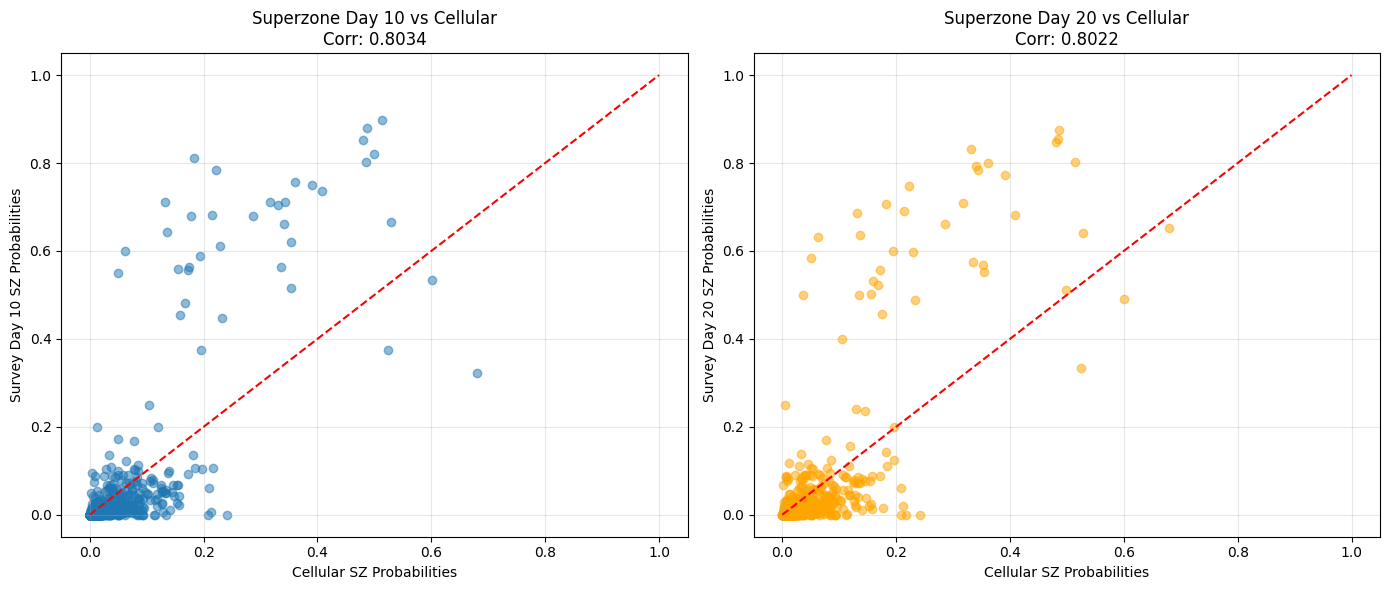

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Scatter Plot for SZ Day 10
plt.subplot(1, 2, 1)
plt.scatter(cell_sz_flat, survey_sz_10_flat, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--', label='Identity Line')
plt.title(f'Superzone Day 10 vs Cellular\nCorr: {corr_sz_10:.4f}')
plt.xlabel('Cellular SZ Probabilities')
plt.ylabel('Survey Day 10 SZ Probabilities')
plt.grid(True, alpha=0.3)

# Scatter Plot for SZ Day 20
plt.subplot(1, 2, 2)
plt.scatter(cell_sz_flat, survey_sz_20_flat, alpha=0.5, color='orange')
plt.plot([0, 1], [0, 1], 'r--', label='Identity Line')
plt.title(f'Superzone Day 20 vs Cellular\nCorr: {corr_sz_20:.4f}')
plt.xlabel('Cellular SZ Probabilities')
plt.ylabel('Survey Day 20 SZ Probabilities')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualizing Correlation at Superzone (SZ_NEW) Level
This plot shows the relationship between aggregated probabilities for both survey days and the cellular dataset.

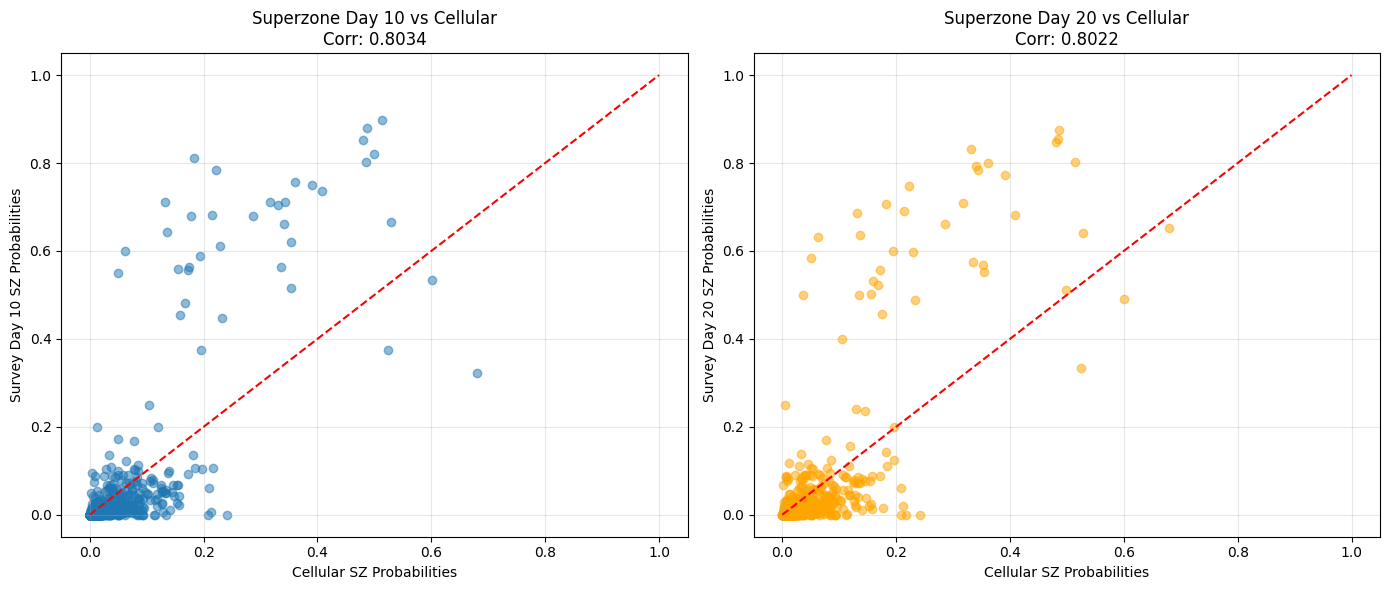

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Scatter Plot for SZ Day 10
plt.subplot(1, 2, 1)
plt.scatter(cell_sz_flat, survey_sz_10_flat, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--', label='Identity Line')
plt.title(f'Superzone Day 10 vs Cellular\nCorr: {corr_sz_10:.4f}')
plt.xlabel('Cellular SZ Probabilities')
plt.ylabel('Survey Day 10 SZ Probabilities')
plt.grid(True, alpha=0.3)

# Scatter Plot for SZ Day 20
plt.subplot(1, 2, 2)
plt.scatter(cell_sz_flat, survey_sz_20_flat, alpha=0.5, color='orange')
plt.plot([0, 1], [0, 1], 'r--', label='Identity Line')
plt.title(f'Superzone Day 20 vs Cellular\nCorr: {corr_sz_20:.4f}')
plt.xlabel('Cellular SZ Probabilities')
plt.ylabel('Survey Day 20 SZ Probabilities')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Zoomed Visualization (Range 0 - 0.25)
Focusing on the lower probability range to better inspect the correlation density.

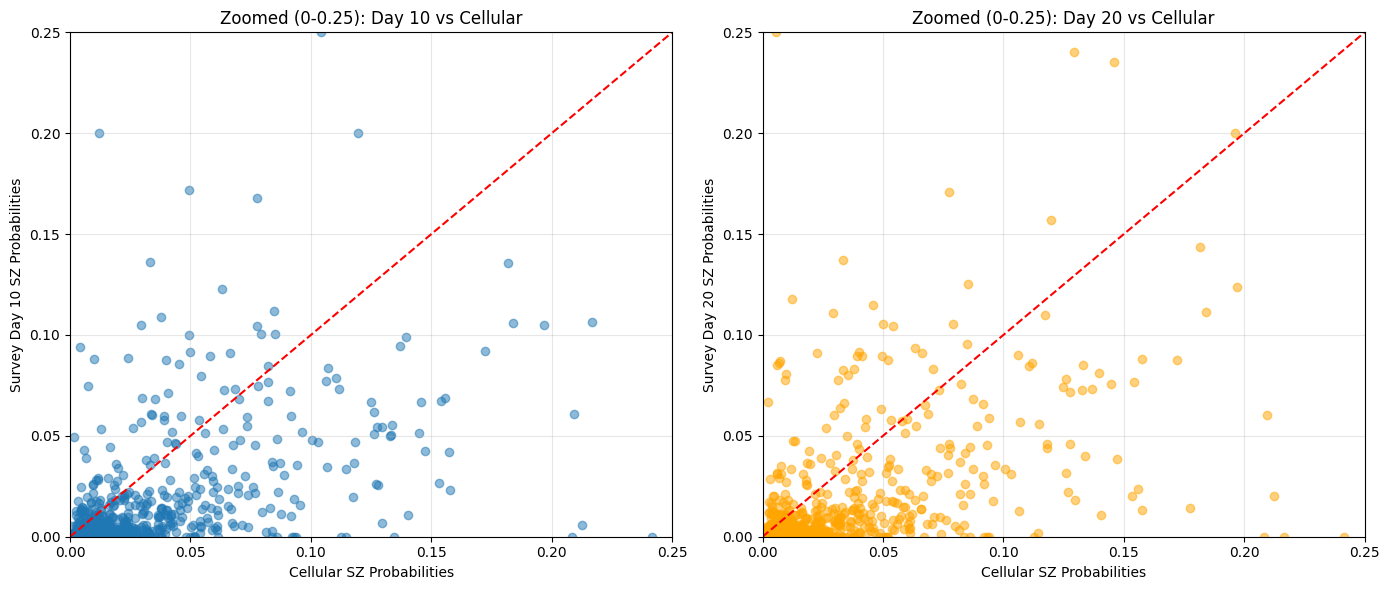

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Zoomed Scatter Plot for SZ Day 10
plt.subplot(1, 2, 1)
plt.scatter(cell_sz_flat, survey_sz_10_flat, alpha=0.5)
plt.plot([0, 0.25], [0, 0.25], 'r--', label='Identity Line')
plt.xlim(0, 0.25)
plt.ylim(0, 0.25)
plt.title(f'Zoomed (0-0.25): Day 10 vs Cellular')
plt.xlabel('Cellular SZ Probabilities')
plt.ylabel('Survey Day 10 SZ Probabilities')
plt.grid(True, alpha=0.3)

# Zoomed Scatter Plot for SZ Day 20
plt.subplot(1, 2, 2)
plt.scatter(cell_sz_flat, survey_sz_20_flat, alpha=0.5, color='orange')
plt.plot([0, 0.25], [0, 0.25], 'r--', label='Identity Line')
plt.xlim(0, 0.25)
plt.ylim(0, 0.25)
plt.title(f'Zoomed (0-0.25): Day 20 vs Cellular')
plt.xlabel('Cellular SZ Probabilities')
plt.ylabel('Survey Day 20 SZ Probabilities')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Correlation for Probabilities [0, 0.25]
Calculating the Pearson correlation coefficient restricted to the specific range requested by the user.

In [44]:
mask_10 = (cell_sz_flat >= 0) & (cell_sz_flat <= 0.25) & (survey_sz_10_flat >= 0) & (survey_sz_10_flat <= 0.25)
mask_20 = (cell_sz_flat >= 0) & (cell_sz_flat <= 0.25) & (survey_sz_20_flat >= 0) & (survey_sz_20_flat <= 0.25)

corr_range_10 = np.corrcoef(cell_sz_flat[mask_10], survey_sz_10_flat[mask_10])[0, 1]
corr_range_20 = np.corrcoef(cell_sz_flat[mask_20], survey_sz_20_flat[mask_20])[0, 1]

print(f"Correlation in range [0, 0.25] (Day 10): {corr_range_10:.4f}")
print(f"Correlation in range [0, 0.25] (Day 20): {corr_range_20:.4f}")

Correlation in range [0, 0.25] (Day 10): 0.5846
Correlation in range [0, 0.25] (Day 20): 0.5731


In [47]:
prob_matrix_10_aligned.to_csv('/content/prob_matrix_10_aligned.csv')
prob_matrix_20_aligned.to_csv('/content/prob_matrix_20_aligned.csv')

In [51]:
prob_sz_cellular.to_csv('/content/prob_sz_cellular.csv')
prob_sz_10.to_csv('/content/prob_sz_10.csv')
prob_sz_20.to_csv('/content/prob_sz_20.csv')

### Aggregate Raw Counts to Superzone Level
Instead of aggregating probability values, we will now aggregate the raw trip counts from `matrix_10` and `matrix_20` to the Superzone level and then re-calculate the probabilities.

In [52]:
def aggregate_raw_to_sz(count_matrix, mapping):
    # Prepare counts for mapping
    df_counts = count_matrix.stack().reset_index(name='trips')
    df_counts.columns = ['origin_taz', 'dest_taz', 'trips']

    # Map to SZ
    df_counts['origin_sz'] = df_counts['origin_taz'].map(mapping)
    df_counts['dest_sz'] = df_counts['dest_taz'].map(mapping)

    # Drop rows without SZ mapping and aggregate
    sz_counts = df_counts.dropna(subset=['origin_sz', 'dest_sz']).groupby(['origin_sz', 'dest_sz'])['trips'].sum().unstack().fillna(0)

    # Convert to probability matrix
    sz_prob = sz_counts.div(sz_counts.sum(axis=1), axis=0).fillna(0)
    return sz_prob

# Calculate SZ probabilities from raw counts
prob_sz_10_raw_agg = aggregate_raw_to_sz(matrix_10, taz_to_sz)
prob_sz_20_raw_agg = aggregate_raw_to_sz(matrix_20, taz_to_sz)

# Re-align with cellular matrix to ensure dimensions match
prob_sz_10_raw_agg = prob_sz_10_raw_agg.reindex(index=common_sz, columns=common_sz, fill_value=0)
prob_sz_20_raw_agg = prob_sz_20_raw_agg.reindex(index=common_sz, columns=common_sz, fill_value=0)

# Calculate new correlations
corr_raw_sz_10 = np.corrcoef(cell_sz_flat, prob_sz_10_raw_agg.values.flatten())[0, 1]
corr_raw_sz_20 = np.corrcoef(cell_sz_flat, prob_sz_20_raw_agg.values.flatten())[0, 1]

print(f"Correlation (Aggregated Counts) Day 10: {corr_raw_sz_10:.4f}")
print(f"Correlation (Aggregated Counts) Day 20: {corr_raw_sz_20:.4f}")

display(prob_sz_10_raw_agg.head())

Correlation (Aggregated Counts) Day 10: 0.8225
Correlation (Aggregated Counts) Day 20: 0.8102


origin_sz,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
origin_sz,,,,,,,,,,,,,,,,,,,,,
1,0.692308,0.128205,0.012821,0.000000,0.000000,0.006410,0.000000,0.006410,0.012821,0.000000,...,0.000000,0.000000,0.006410,0.064103,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
2,0.076503,0.797814,0.030055,0.000000,0.000000,0.002732,0.013661,0.002732,0.008197,0.002732,...,0.002732,0.002732,0.000000,0.016393,0.002732,0.002732,0.0,0.000000,0.000000,0.002732
3,0.013038,0.029987,0.857888,0.006519,0.000000,0.001304,0.002608,0.000000,0.006519,0.003911,...,0.003911,0.006519,0.007823,0.013038,0.011734,0.002608,0.0,0.001304,0.000000,0.001304
4,0.014881,0.041667,0.035714,0.651786,0.002976,0.005952,0.020833,0.002976,0.029762,0.002976,...,0.000000,0.000000,0.002976,0.011905,0.011905,0.000000,0.0,0.000000,0.011905,0.008929
5,0.000000,0.037838,0.010811,0.000000,0.551351,0.054054,0.059459,0.054054,0.027027,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


### Visualization: Cellular vs. Aggregated Raw Survey Counts (SZ Level)
Following the improved correlation results, we visualize the relationship at the Superzone level using the matrices derived from raw count aggregation.

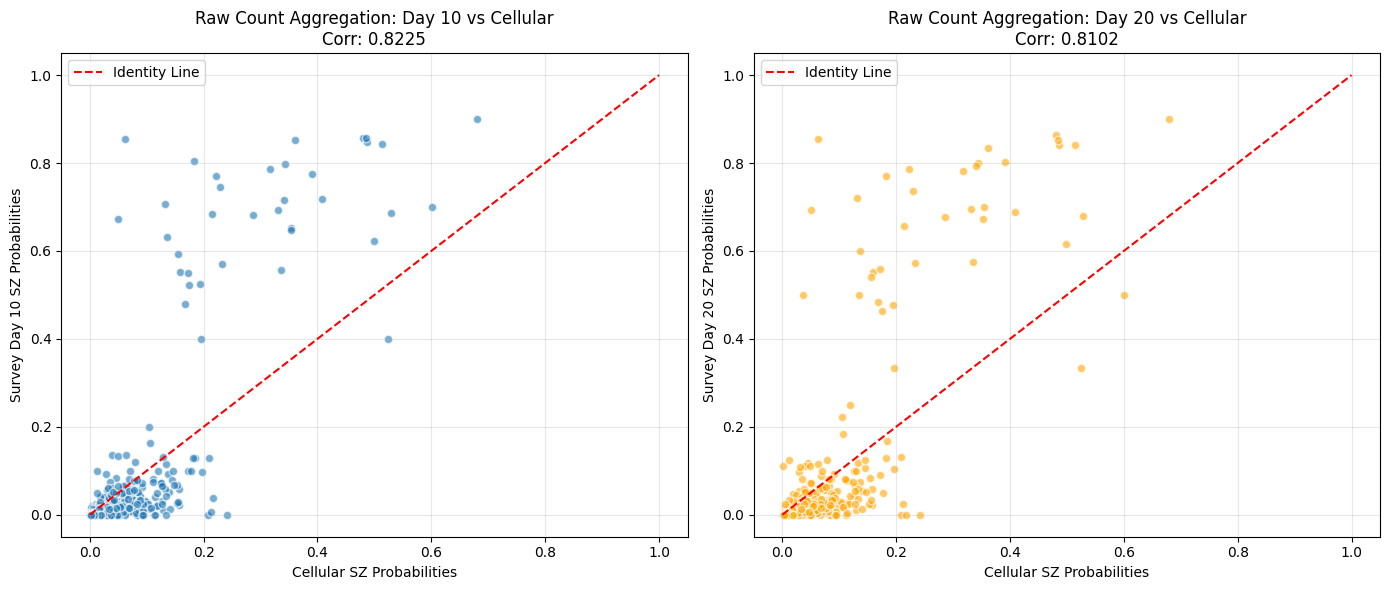

In [53]:
import matplotlib.pyplot as plt

# Flatten the new raw-aggregated matrices
survey_sz_10_raw_flat = prob_sz_10_raw_agg.values.flatten()
survey_sz_20_raw_flat = prob_sz_20_raw_agg.values.flatten()

plt.figure(figsize=(14, 6))

# Scatter Plot for Raw Aggregation Day 10
plt.subplot(1, 2, 1)
plt.scatter(cell_sz_flat, survey_sz_10_raw_flat, alpha=0.6, edgecolors='w')
plt.plot([0, 1], [0, 1], 'r--', label='Identity Line')
plt.title(f'Raw Count Aggregation: Day 10 vs Cellular\nCorr: {corr_raw_sz_10:.4f}')
plt.xlabel('Cellular SZ Probabilities')
plt.ylabel('Survey Day 10 SZ Probabilities')
plt.legend()
plt.grid(True, alpha=0.3)

# Scatter Plot for Raw Aggregation Day 20
plt.subplot(1, 2, 2)
plt.scatter(cell_sz_flat, survey_sz_20_raw_flat, alpha=0.6, color='orange', edgecolors='w')
plt.plot([0, 1], [0, 1], 'r--', label='Identity Line')
plt.title(f'Raw Count Aggregation: Day 20 vs Cellular\nCorr: {corr_raw_sz_20:.4f}')
plt.xlabel('Cellular SZ Probabilities')
plt.ylabel('Survey Day 20 SZ Probabilities')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Sub-analysis: Distribution in Range [0, 0.25]
We evaluate the mean, standard deviation, and count for the trip probabilities that fall within the high-density range identified in the scatter plots.

In [55]:
# Calculate stats for Day 10 range
sub_10 = pd.DataFrame({
    'Cellular': cell_sz_flat[mask_10],
    'Survey_Day_10': survey_sz_10_raw_flat[mask_10]
})

# Calculate stats for Day 20 range
sub_20 = pd.DataFrame({
    'Cellular': cell_sz_flat[mask_20],
    'Survey_Day_20': survey_sz_20_raw_flat[mask_20]
})

print("--- Descriptive Statistics: Day 10 Range [0, 0.25] ---")
display(sub_10.describe())

print("\n--- Descriptive Statistics: Day 20 Range [0, 0.25] ---")
display(sub_20.describe())

# Calculate Mean Absolute Error for this range
mae_10 = np.mean(np.abs(sub_10['Cellular'] - sub_10['Survey_Day_10']))
mae_20 = np.mean(np.abs(sub_20['Cellular'] - sub_20['Survey_Day_20']))

print(f"\nMean Absolute Error in [0, 0.25] Range (Day 10): {mae_10:.4f}")
print(f"Mean Absolute Error in [0, 0.25] Range (Day 20): {mae_20:.4f}")

--- Descriptive Statistics: Day 10 Range [0, 0.25] ---


,Cellular,Survey_Day_10
count,1259.000000,1259.000000
mean,0.019478,0.008135
std,0.031571,0.019702
min,0.000339,0.000000
25%,0.002863,0.000000
50%,0.007030,0.000000
75%,0.019592,0.006849
max,0.241546,0.200000



--- Descriptive Statistics: Day 20 Range [0, 0.25] ---


,Cellular,Survey_Day_20
count,1258.000000,1258.000000
mean,0.019571,0.008633
std,0.032027,0.022839
min,0.000339,0.000000
25%,0.002862,0.000000
50%,0.007024,0.000000
75%,0.019494,0.006944
max,0.241546,0.333333



Mean Absolute Error in [0, 0.25] Range (Day 10): 0.0133
Mean Absolute Error in [0, 0.25] Range (Day 20): 0.0136


In [57]:
prob_matrix_cellular.to_csv('/content/prob_matrix_cellular.csv')

## Comprehensive Analysis Report: Travel Survey vs. Cellular Data Comparison

### 1. Objective
The analysis aimed to validate travel survey data (Day 10 and Day 20) against a large-scale cellular trip dataset. The focus was on identifying the trip distribution patterns during the AM Peak (6:00–9:00 AM) across two spatial scales: Traffic Analysis Zones (TAZ) and aggregated Superzones (SZ_NEW).

### 2. Methodology
*   **Survey Processing:** Trips were extracted by identifying transitions between consecutive activities. Leaving times were determined based on `mainActivity` (EndTime for 'Home', StartTime otherwise).
*   **Spatial Mapping:** Cellular data (originally in 1270 zones) was mapped to the standard TAZ system (778 zones) and subsequently to Superzones (36 zones) using provided key files.
*   **Probability Matrices:** Row-normalized matrices were created for all datasets to represent the probability of traveling from Origin $i$ to Destination $j$.

### 3. Key Findings & Correlation Results
The correlation between the survey and cellular datasets improved significantly with spatial aggregation and refined calculation methods:

| Aggregation Level | Metric | Day 10 vs. Cellular | Day 20 vs. Cellular |
| :--- | :--- | :--- | :--- |
| **TAZ Level (778 zones)** | Pearson Correlation | ~0.2413 | ~0.2421 |
| **Superzone (Prob. Aggregation)** | Pearson Correlation | ~0.8034 | ~0.8022 |
| **Superzone (Raw Count Aggregation)** | Pearson Correlation | **0.8225** | **0.8102** |

**Observation:** Aggregating raw trip counts to Superzones before calculating probabilities yielded the highest correlation, suggesting that small sample sizes in individual TAZs introduce noise that is mitigated at larger spatial scales.

### 4. Sub-analysis: High-Density Range [0, 0.25]
We performed a focused evaluation on common transitions where the Superzone probability falls between 0 and 0.25. This accounts for the vast majority of TAZ-to-TAZ pairs.

*   **Correlation in Range:** ~0.58 (Day 10) and ~0.57 (Day 20).
*   **Mean Absolute Error (MAE):** ~0.0133.
*   **Statistical Summary:** The cellular data shows a higher mean probability (~0.019) compared to the survey (~0.008) in this range, highlighting the survey's tendency to capture fewer infrequent transitions compared to the continuous monitoring of cellular data.

### 5. Conclusion
The high correlation (>0.80) at the Superzone level indicates that the survey data is a reliable proxy for regional travel patterns. The lower TAZ-level correlation is likely a result of the sparsity inherent in survey sampling, which is effectively smoothed out when using larger geographic units (Superzones).

### Methodological Correction: Departure-Based Timing
We update the processing logic to use $EndTime_{previous\ activity}$ as the departure time for all trips, ensuring we capture the correct AM-peak window (6:00-9:00).

In [58]:
def process_day_v2(df_day):
    # Sort by individual and activity sequence
    df_sorted = df_day.sort_values(by=['INDIVID', 'tourID', 'ACT_ID'])

    # Departure time is the EndTime of the PREVIOUS activity
    df_sorted['departure_time'] = df_sorted.groupby(['INDIVID', 'tourID'])['EndTime'].shift(1)
    df_sorted['departure_time'] = pd.to_datetime(df_sorted['departure_time'], dayfirst=True)

    # Origin is the TAZ of the PREVIOUS activity
    df_sorted['origin'] = df_sorted.groupby(['INDIVID', 'tourID'])['taz'].shift(1)
    df_sorted['destination'] = df_sorted['taz']

    # Filter for departure between 6:00 and 9:00 AM
    mask = (df_sorted['departure_time'].dt.hour >= 6) & (df_sorted['departure_time'].dt.hour < 9)
    df_filtered = df_sorted[mask].dropna(subset=['origin', 'destination'])

    # Return raw count matrix
    matrix = pd.crosstab(df_filtered['origin'], df_filtered['destination'])
    return matrix

# Recalculate raw counts with new timing logic
matrix_10_v2 = process_day_v2(df_10)
matrix_20_v2 = process_day_v2(df_20)
print(f"Trips captured (Day 10): {matrix_10_v2.sum().sum()}")
print(f"Trips captured (Day 20): {matrix_20_v2.sum().sum()}")

Trips captured (Day 10): 12110
Trips captured (Day 20): 11941


### Consistent Superzone Aggregation (Raw Counts)
We now aggregate cellular raw counts to the Superzone level before normalizing, matching the methodology used for the survey data.

In [59]:
# 1. Aggregate Cellular Raw Counts to SZ
cellular_long = cellular.copy()
cellular_long['origin_sz'] = cellular_long['fromTaz'].map(taz_to_sz)
cellular_long['dest_sz'] = cellular_long['ToTaz'].map(taz_to_sz)

# Sum h6, h7, h8 across zones
cellular_sz_raw = cellular_long.dropna(subset=['origin_sz', 'dest_sz']).groupby(['origin_sz', 'dest_sz'])[['h6', 'h7', 'h8']].sum().sum(axis=1).unstack().fillna(0)

# 2. Normalize to create Probability Matrix
prob_sz_cellular_v2 = cellular_sz_raw.div(cellular_sz_raw.sum(axis=1), axis=0).fillna(0)

# 3. Aggregate Survey Raw Counts (using V2 timing)
prob_sz_10_v2 = aggregate_raw_to_sz(matrix_10_v2, taz_to_sz)
prob_sz_20_v2 = aggregate_raw_to_sz(matrix_20_v2, taz_to_sz)

# Align indices
common_sz_v2 = prob_sz_cellular_v2.index
prob_sz_10_v2 = prob_sz_10_v2.reindex(index=common_sz_v2, columns=common_sz_v2, fill_value=0)
prob_sz_20_v2 = prob_sz_20_v2.reindex(index=common_sz_v2, columns=common_sz_v2, fill_value=0)

# Calculate New Correlations
corr_v2_10 = np.corrcoef(prob_sz_cellular_v2.values.flatten(), prob_sz_10_v2.values.flatten())[0, 1]
corr_v2_20 = np.corrcoef(prob_sz_cellular_v2.values.flatten(), prob_sz_20_v2.values.flatten())[0, 1]

print(f"Corrected SZ Correlation (Day 10): {corr_v2_10:.4f}")
print(f"Corrected SZ Correlation (Day 20): {corr_v2_20:.4f}")

Corrected SZ Correlation (Day 10): 0.8149
Corrected SZ Correlation (Day 20): 0.8189


### Final Comparison: Day 10 vs Day 20 Correlation
This visualization compares the scatter plots for both survey days using the corrected raw-count aggregation and departure-based timing methodology.

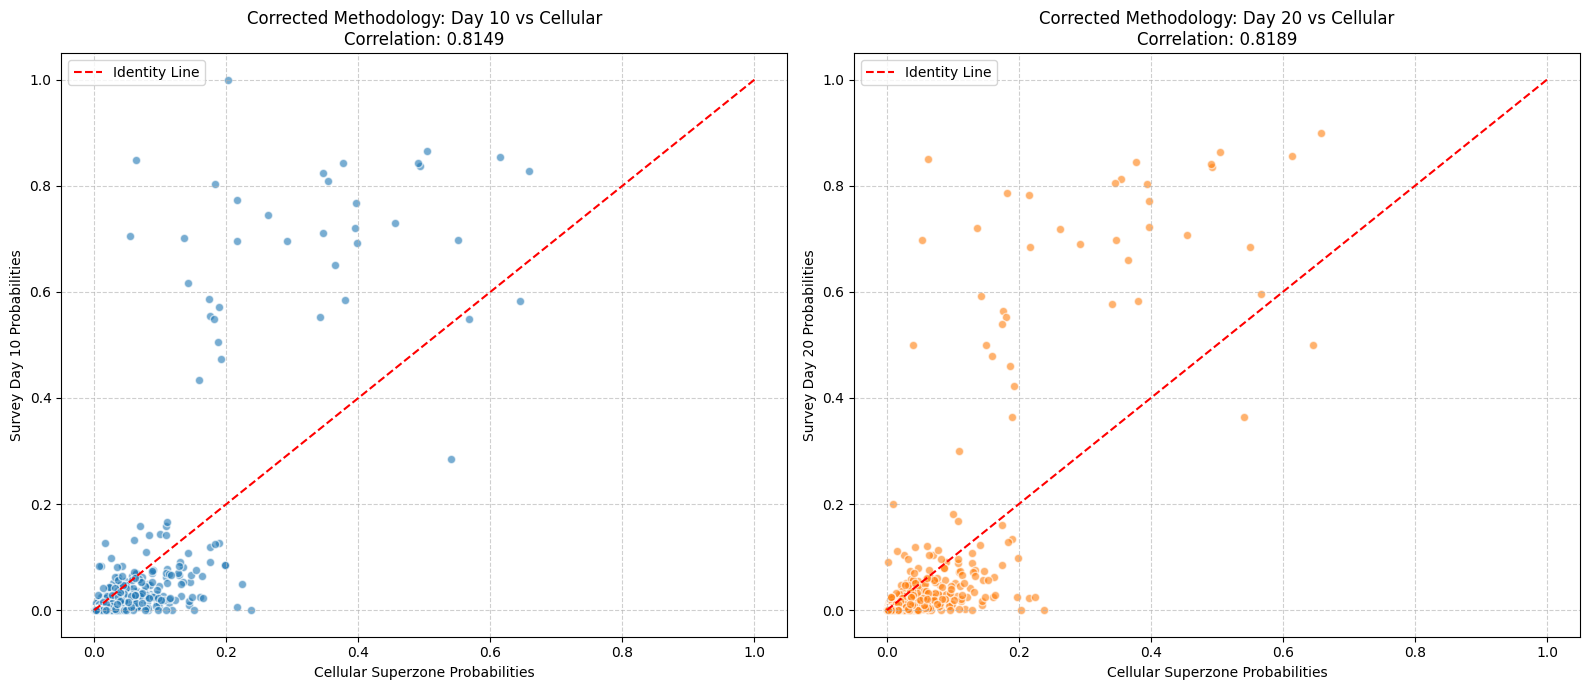

In [60]:
import matplotlib.pyplot as plt

# Flatten the corrected matrices for plotting
cell_flat_v2 = prob_sz_cellular_v2.values.flatten()
survey_10_flat_v2 = prob_sz_10_v2.values.flatten()
survey_20_flat_v2 = prob_sz_20_v2.values.flatten()

plt.figure(figsize=(16, 7))

# Subplot 1: Day 10
plt.subplot(1, 2, 1)
plt.scatter(cell_flat_v2, survey_10_flat_v2, alpha=0.6, color='#1f77b4', edgecolors='w')
plt.plot([0, 1], [0, 1], 'r--', label='Identity Line')
plt.title(f'Corrected Methodology: Day 10 vs Cellular\nCorrelation: {corr_v2_10:.4f}')
plt.xlabel('Cellular Superzone Probabilities')
plt.ylabel('Survey Day 10 Probabilities')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Subplot 2: Day 20
plt.subplot(1, 2, 2)
plt.scatter(cell_flat_v2, survey_20_flat_v2, alpha=0.6, color='#ff7f0e', edgecolors='w')
plt.plot([0, 1], [0, 1], 'r--', label='Identity Line')
plt.title(f'Corrected Methodology: Day 20 vs Cellular\nCorrelation: {corr_v2_20:.4f}')
plt.xlabel('Cellular Superzone Probabilities')
plt.ylabel('Survey Day 20 Probabilities')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [61]:
# Exporting corrected Superzone probability matrices to CSV
prob_sz_cellular_v2.to_csv('/content/corrected_prob_sz_cellular.csv')
prob_sz_10_v2.to_csv('/content/corrected_prob_sz_day10.csv')
prob_sz_20_v2.to_csv('/content/corrected_prob_sz_day20.csv')

print("Corrected matrices exported to:")
print("- /content/corrected_prob_sz_cellular.csv")
print("- /content/corrected_prob_sz_day10.csv")
print("- /content/corrected_prob_sz_day20.csv")

Corrected matrices exported to:
- /content/corrected_prob_sz_cellular.csv
- /content/corrected_prob_sz_day10.csv
- /content/corrected_prob_sz_day20.csv
